In [ ]:
import cv2
import os
import matplotlib.pyplot as plt

# 1. Die relativen Pfade definieren (aus der Sicht des Notebooks)
src_path = '../data/raw/source.tif'
target_path = '../data/raw/target.tif'

# 2. Kurzer Sicherheits-Check: Existieren die Dateien dort überhaupt?
if not os.path.exists(src_path):
    print(f"❌ FEHLER: Konnte source.jpg nicht finden unter: {os.path.abspath(src_path)}")
elif not os.path.exists(target_path):
    print(f"❌ FEHLER: Konnte target.jpg nicht finden unter: {os.path.abspath(target_path)}")
else:
    print("✅ Dateien auf der Festplatte gefunden! Lade Bilder in den Arbeitsspeicher...")
    
    # 3. Bilder mit OpenCV in den RAM laden
    src_img = cv2.imread(src_path)
    target_img = cv2.imread(target_path)
    
    # OpenCV lädt Bilder als BGR, für die Anzeige in Matplotlib brauchen wir RGB
    src_rgb = cv2.cvtColor(src_img, cv2.COLOR_BGR2RGB)
    target_rgb = cv2.cvtColor(target_img, cv2.COLOR_BGR2RGB)
    
    # 4. Bilder anzeigen, um sicherzugehen, dass sie da sind
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(src_rgb)
    axes[0].set_title("Source Image")
    axes[0].axis("off")
    
    axes[1].imshow(target_rgb)
    axes[1].set_title("Target Image")
    axes[1].axis("off")
    
    plt.show()

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# Notebook Magic Command für inline Plots
%matplotlib inline

# Standardgröße für unsere Plots (Breite, Höhe) - ideal für 3 Bilder nebeneinander
plt.rcParams['figure.figsize'] = (18, 6)

Reinhard Logik

In [ ]:
def get_mean_std(image):
    mean, std = cv2.meanStdDev(image)
    return mean.flatten(), std.flatten()

def normalize_stain_reinhard(src_img, target_img):
    # Konvertierung zu LAB & float32
    src_lab = cv2.cvtColor(src_img, cv2.COLOR_BGR2LAB).astype(np.float32)
    target_lab = cv2.cvtColor(target_img, cv2.COLOR_BGR2LAB).astype(np.float32)

    # Statistiken
    src_mean, src_std = get_mean_std(src_lab)
    target_mean, target_std = get_mean_std(target_lab)

    # Kanäle splitten
    l, a, b = cv2.split(src_lab)

    # Zero-Division Schutz
    src_std[src_std == 0] = 1e-5

    # Reinhard Gleichung
    l_norm = (l - src_mean[0]) * (target_std[0] / src_std[0]) + target_mean[0]
    a_norm = (a - src_mean[1]) * (target_std[1] / src_std[1]) + target_mean[1]
    b_norm = (b - src_mean[2]) * (target_std[2] / src_std[2]) + target_mean[2]

    # Merge, Clip und zurück zu BGR (8-Bit)
    result_lab = cv2.merge((l_norm, a_norm, b_norm))
    result_lab = np.clip(result_lab, 0, 255).astype(np.uint8)
    result_bgr = cv2.cvtColor(result_lab, cv2.COLOR_LAB2BGR)

    return result_bgr

In [ ]:
# Hilfsfunktion für die korrekte Farbdarstellung im Plot
def bgr_to_rgb(img):
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# 1. Bilder laden (Pfade anpassen, falls nötig! '../' geht eine Ebene hoch aus dem notebook Ordner)
src_path = '../data/raw/source.tif'
target_path = '../data/raw/target.tif'

src_img = cv2.imread(src_path)
target_img = cv2.imread(target_path)

# Kurzer Check, ob die Bilder gefunden wurden
if src_img is None or target_img is None:
    print("Fehler: Bilder konnten nicht geladen werden. Bitte Pfade prüfen!")
else:
    # 2. Die Normalisierung anwenden (wie das Anwenden einer dynamischen LUT)
    result_img = normalize_stain_reinhard(src_img, target_img)

    # 3. Visualisierung (Das Portfolio-Layout)
    fig, axes = plt.subplots(1, 3)
    
    axes[0].imshow(bgr_to_rgb(src_img))
    axes[0].set_title('1. Source (Original)')
    axes[0].axis('off') # Versteckt die Pixel-Achsen für einen cleanen Look
    
    axes[1].imshow(bgr_to_rgb(target_img))
    axes[1].set_title('2. Target (Reference Style)')
    axes[1].axis('off')
    
    axes[2].imshow(bgr_to_rgb(result_img))
    axes[2].set_title('3. Result (Normalized)')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()

In [ ]:
def get_tissue_mask(image):
    """Generiert eine Maske für das Gewebe (Weiß=Gewebe, Schwarz=Glas)."""
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    _, mask = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    return mask

def get_mean_std_masked(image, mask=None):
    """Berechnet Mean und Std, berücksichtigt dabei nur maskierte Pixel."""
    mean, std = cv2.meanStdDev(image, mask=mask)
    return mean.flatten(), std.flatten()

def normalize_stain_reinhard_custom_mask(src_img, target_img, src_thresh=255, target_thresh=210):
    """Reinhard mit manuell einstellbaren Masken."""
    src_lab = cv2.cvtColor(src_img, cv2.COLOR_BGR2LAB).astype(np.float32)
    target_lab = cv2.cvtColor(target_img, cv2.COLOR_BGR2LAB).astype(np.float32)

    # Hier nutzen wir jetzt deine neuen manuellen Masken!
    src_mask = get_tissue_mask_manual(src_img, threshold_value=src_thresh)
    target_mask = get_tissue_mask_manual(target_img, threshold_value=target_thresh)

    src_mean, src_std = get_mean_std_masked(src_lab, mask=src_mask)
    target_mean, target_std = get_mean_std_masked(target_lab, mask=target_mask)

    src_std[src_std == 0] = 1e-5

    l, a, b = cv2.split(src_lab)
    l_norm = (l - src_mean[0]) * (target_std[0] / src_std[0]) + target_mean[0]
    a_norm = (a - src_mean[1]) * (target_std[1] / src_std[1]) + target_mean[1]
    b_norm = (b - src_mean[2]) * (target_std[2] / src_std[2]) + target_mean[2]

    result_lab = cv2.merge((l_norm, a_norm, b_norm))
    result_lab = np.clip(result_lab, 0, 255).astype(np.uint8)
    return cv2.cvtColor(result_lab, cv2.COLOR_LAB2BGR)

# ==========================================
# AUSFÜHRUNG & VISUALISIERUNG
# ==========================================
# (Wir nutzen hier src_img und target_img, die du im letzten Schritt geladen hast)

result_img_masked = normalize_stain_reinhard_masked(src_img, target_img)

# Portfolio-tauglicher Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(cv2.cvtColor(src_img, cv2.COLOR_BGR2RGB))
axes[0].set_title('1. Source (Original)')
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(target_img, cv2.COLOR_BGR2RGB))
axes[1].set_title('2. Target (Reference)')
axes[1].axis('off')

axes[2].imshow(cv2.cvtColor(result_img_masked, cv2.COLOR_BGR2RGB))
axes[2].set_title('3. Result (Masked Reinhard)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
def get_tissue_mask_manual(image, threshold_value=210):
    """
    Manuelle Gewebe-Maske.
    threshold_value: Pixelwert (0-255). Alles, was im Graubild DUNKELER 
    als dieser Wert ist, wird als Gewebe (Weiß) maskiert.
    """
    # 1. Bild in Graustufen umwandeln (Luminanz)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
    # 2. Manueller Threshold (ohne + cv2.THRESH_OTSU)
    _, mask = cv2.threshold(gray, threshold_value, 255, cv2.THRESH_BINARY_INV)
    
    return mask

# ==========================================
# MASKEN-STUDIO: Finde den perfekten Wert
# ==========================================
# Wir testen 3 verschiedene Werte: z.B. 180 (sehr streng), 210 (moderat), 235 (sehr tolerant)
thresh_1 = 180
thresh_2 = 210
thresh_3 = 235

mask_1 = get_tissue_mask_manual(src_img, threshold_value=thresh_1)
mask_2 = get_tissue_mask_manual(src_img, threshold_value=thresh_2)
mask_3 = get_tissue_mask_manual(src_img, threshold_value=thresh_3)

# Visualisierung
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(cv2.cvtColor(src_img, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(mask_1, cmap='gray')
axes[1].set_title(f'Maske (Threshold = {thresh_1})')
axes[1].axis('off')

axes[2].imshow(mask_2, cmap='gray')
axes[2].set_title(f'Maske (Threshold = {thresh_2})')
axes[2].axis('off')

axes[3].imshow(mask_3, cmap='gray')
axes[3].set_title(f'Maske (Threshold = {thresh_3})')
axes[3].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
def normalize_stain_reinhard_custom_mask(src_img, target_img, src_thresh=210, target_thresh=210):
    """Reinhard mit manuell einstellbaren Masken."""
    src_lab = cv2.cvtColor(src_img, cv2.COLOR_BGR2LAB).astype(np.float32)
    target_lab = cv2.cvtColor(target_img, cv2.COLOR_BGR2LAB).astype(np.float32)

    # Hier nutzen wir jetzt deine neuen manuellen Masken!
    src_mask = get_tissue_mask_manual(src_img, threshold_value=src_thresh)
    target_mask = get_tissue_mask_manual(target_img, threshold_value=target_thresh)

    src_mean, src_std = get_mean_std_masked(src_lab, mask=src_mask)
    target_mean, target_std = get_mean_std_masked(target_lab, mask=target_mask)

    src_std[src_std == 0] = 1e-5

    l, a, b = cv2.split(src_lab)
    l_norm = (l - src_mean[0]) * (target_std[0] / src_std[0]) + target_mean[0]
    a_norm = (a - src_mean[1]) * (target_std[1] / src_std[1]) + target_mean[1]
    b_norm = (b - src_mean[2]) * (target_std[2] / src_std[2]) + target_mean[2]

    result_lab = cv2.merge((l_norm, a_norm, b_norm))
    result_lab = np.clip(result_lab, 0, 255).astype(np.uint8)
    return cv2.cvtColor(result_lab, cv2.COLOR_LAB2BGR)

Reinhard Logik mit Luma Maske

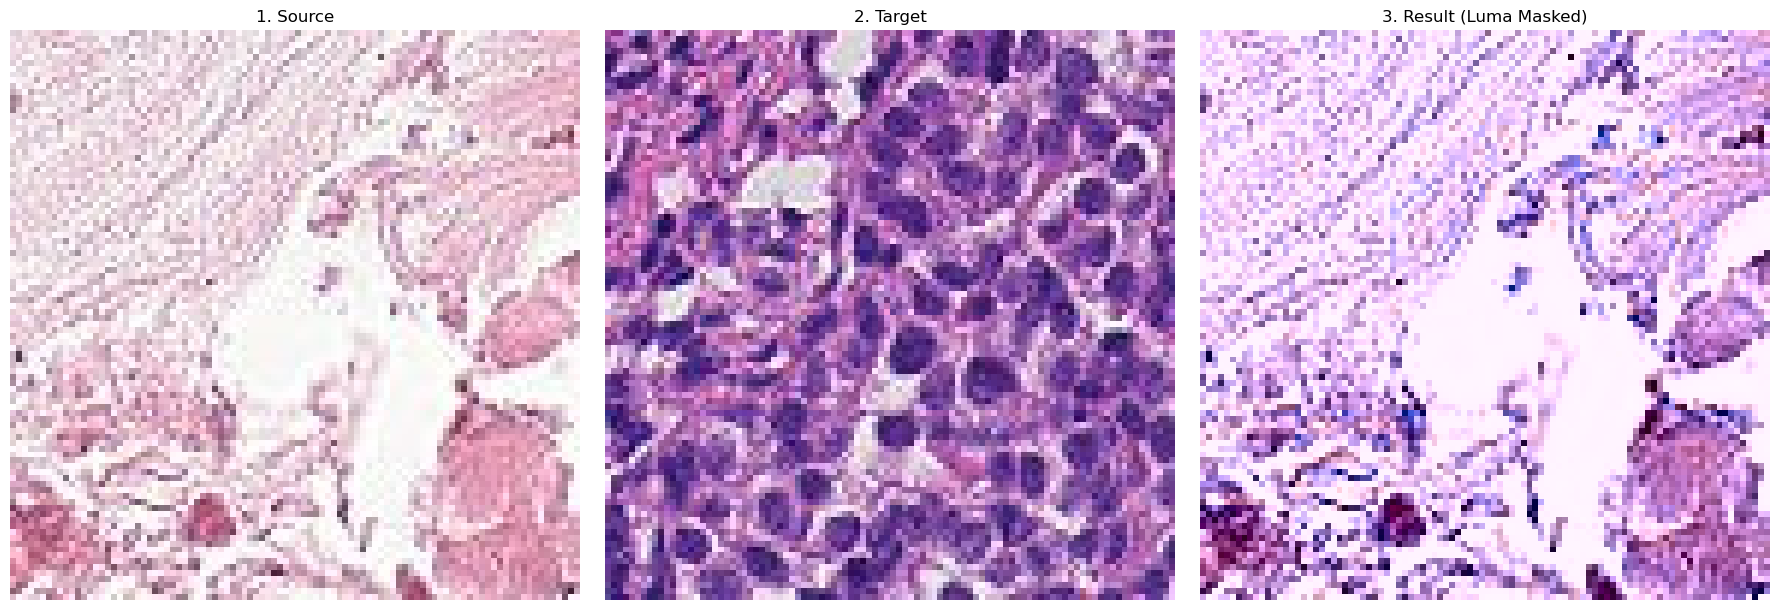

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# --- 1. HILFSFUNKTIONEN ---
def bgr_to_rgb(img):
    """Konvertiert BGR (OpenCV) zu RGB (Matplotlib) für korrekte Farben im Plot."""
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def get_tissue_mask_manual(image, threshold_value=255):
    """Erstellt eine Maske basierend auf der Helligkeit (Luma-Key)."""
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    # THRESH_BINARY_INV: Alles was dunkler als 'threshold_value' ist, wird Weiß (Gewebe)
    _, mask = cv2.threshold(gray, threshold_value, 255, cv2.THRESH_BINARY_INV)
    return mask

def get_mean_std_masked(image, mask=None):
    """Berechnet Mittelwert und Standardabweichung nur für das maskierte Gewebe."""
    mean, std = cv2.meanStdDev(image, mask=mask)
    return mean.flatten(), std.flatten()

# --- 2. DIE HAUPTFUNKTION ---
def normalize_stain_reinhard_custom(src_img, target_img, src_thresh=210, target_thresh=210):
    """Reinhard-Normalisierung mit manuell einstellbaren Luma-Masken."""
    src_lab = cv2.cvtColor(src_img, cv2.COLOR_BGR2LAB).astype(np.float32)
    target_lab = cv2.cvtColor(target_img, cv2.COLOR_BGR2LAB).astype(np.float32)

    # Masken generieren
    src_mask = get_tissue_mask_manual(src_img, threshold_value=src_thresh)
    target_mask = get_tissue_mask_manual(target_img, threshold_value=target_thresh)

    # Statistiken anhand der Masken berechnen
    src_mean, src_std = get_mean_std_masked(src_lab, mask=src_mask)
    target_mean, target_std = get_mean_std_masked(target_lab, mask=target_mask)

    src_std[src_std == 0] = 1e-5 # Zero-Division-Schutz

    # Reinhard-Formel auf alle Kanäle anwenden
    l, a, b = cv2.split(src_lab)
    l_norm = (l - src_mean[0]) * (target_std[0] / src_std[0]) + target_mean[0]
    a_norm = (a - src_mean[1]) * (target_std[1] / src_std[1]) + target_mean[1]
    b_norm = (b - src_mean[2]) * (target_std[2] / src_std[2]) + target_mean[2]

    # Zusammenfügen und zurückwandeln
    result_lab = cv2.merge((l_norm, a_norm, b_norm))
    result_lab = np.clip(result_lab, 0, 255).astype(np.uint8)
    
    return cv2.cvtColor(result_lab, cv2.COLOR_LAB2BGR)

# --- 3. AUSFÜHRUNG & VISUALISIERUNG ---
# Pfade (Bitte prüfen, ob sie für dein Setup stimmen)
src_path = '../data/raw/source.tif'
target_path = '../data/raw/target.tif'

if os.path.exists(src_path) and os.path.exists(target_path):
    src_img = cv2.imread(src_path)
    target_img = cv2.imread(target_path)

    # Hier kannst du die Thresholds anpassen!
    result_img = normalize_stain_reinhard_custom(src_img, target_img, src_thresh=190, target_thresh=210)

    # Plotten
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    axes[0].imshow(bgr_to_rgb(src_img))
    axes[0].set_title('1. Source')
    axes[0].axis('off')
    
    axes[1].imshow(bgr_to_rgb(target_img))
    axes[1].set_title('2. Target')
    axes[1].axis('off')
    
    axes[2].imshow(bgr_to_rgb(result_img))
    axes[2].set_title('3. Result (Luma Masked)')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()
else:
    print("Bilder nicht gefunden!")